# **`This notebook represents the bias detection in the datset using aif360`**

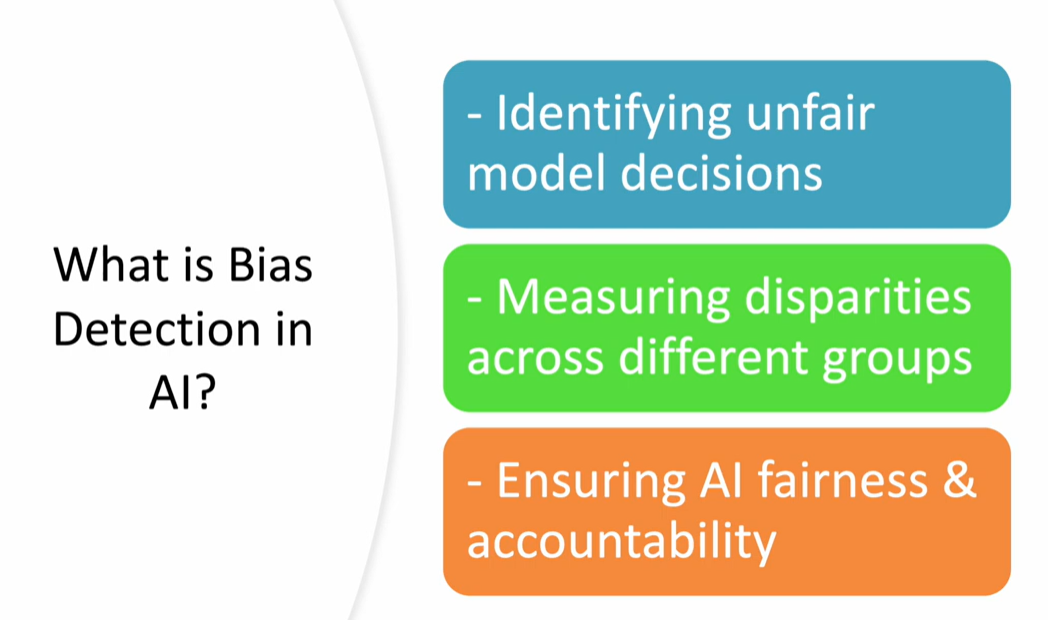

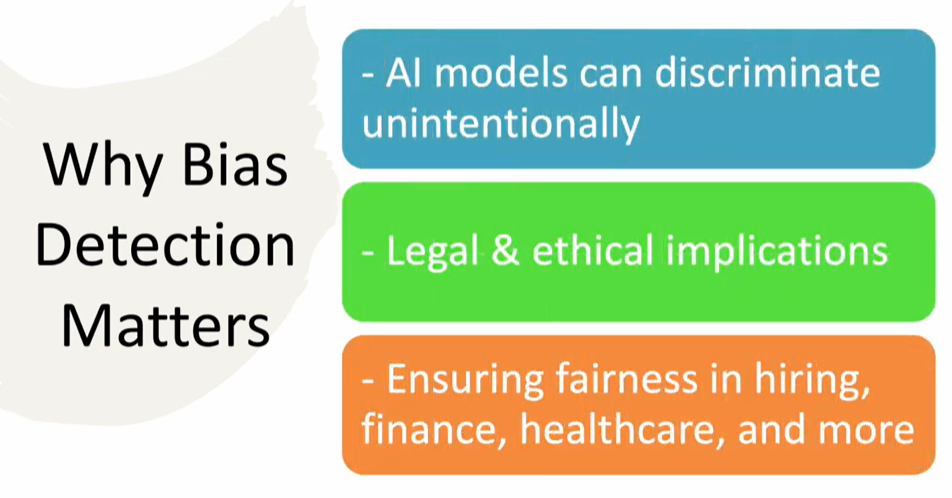

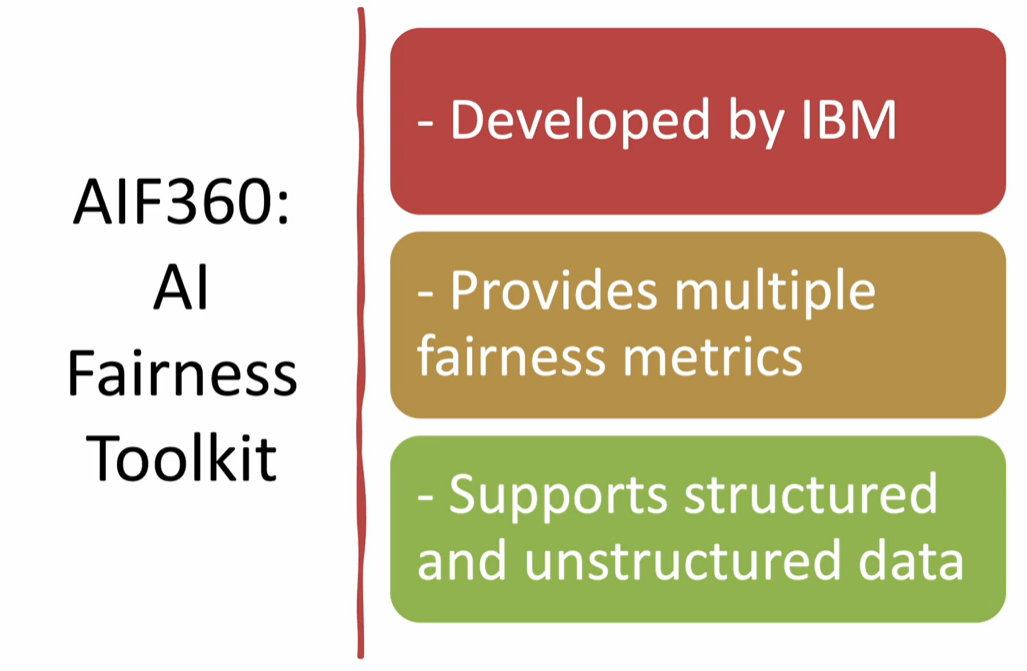

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
pip install aif360


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/python/cleanedDataset.csv')
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,2,8,0
1,49,0,1,8,1,1,1,10,3
2,37,1,2,2,2,1,2,7,3
3,33,0,1,3,4,0,1,8,3
4,27,0,2,2,1,1,1,6,3


> Variable protégé


Une protected variable est une caractéristique sensible d’une personne, que le modèle ne doit pas utiliser (ou doit utiliser avec beaucoup de précautions), car cela peut conduire à de la discrimination.
A savoir: Sexe / genre (homme, femme),Âge,Origine ethnique, Religion, Nationalité, Handicap, Situation familiale.

Pour le jeu de données que nous utilisons les vaiables protégés peuvent étre:

**Age, Gender.**





> Variables proxy:


**MaritalStatus :** fortement corrélé avec l'age et Gender

Family responsibilities

Can cause indirect discrimination


**DistanceFromHome :** variable proxy pour l'age


Can reflect:

Socioeconomic status

Family situation

Residential segregation


**WorkLifeBalance :** Variable proxy pour l'age et le Gender

Can reflect:

Family load

Gender roles

Age-related constraints

**JobRole_**

Souvent corrélé à :

le genre (ex. Sales vs R&D)

l’âge (postes seniors)

parfois le niveau social


**Department_* (ex: Research & Development)**


Corrélée au genre / âge / carrière


**BusinessTravel_* (Travel_Frequently / Travel_Rarely)**

lié aux responsabilités familiales, donc Proxy de genre et âge


**TrainingTimesLastYear**


Les jeunes souvent plus de formations, et les seniors moins de formations, d'où
Proxy léger de l’âge

# Testing which features are more baising the modele

# **Protected variables:**

# **Gender:**

In [ ]:
protected_attribute = "Gender"

privileged_groups = [{protected_attribute: 1}]   # Male
unprivileged_groups = [{protected_attribute: 0}] # Female

aif = BinaryLabelDataset(
    df=df,
    label_names=["Attrition"],
    protected_attribute_names=[protected_attribute]
)


In [ ]:
metric_before = BinaryLabelDatasetMetric(
    aif,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Gender):", metric_before.disparate_impact())
print("Statistical Parity Diff (Gender):", metric_before.statistical_parity_difference())


Disparate Impact (Gender): 0.87
Statistical Parity Diff (Gender): -0.022108843537414963


**`DI indecates that the bias is generally acceptable`**

**`SPD indecates a very small bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







# **Age:**

https://www.linkedin.com/pulse/how-old-too-when-comes-hiring-hrinnovateorg-mchke

How old is too old when it comes to hiring? (LinkedIn)
> In reality though, younger means less than 40, definitely younger than 50. Never ever older than 50. 50 is some kind of gateway into joblessness and invisibility. Below 40 is the hottest time to be on the market, so your optimum career window in this current global job market is 20 – 40. Best get at it.





In [ ]:
# Assuming 'Age' is scaled 0-1
import pandas as pd

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

df['AgeGroup'] = df['Age'].apply(age_bin)


In [ ]:
protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees


In [ ]:
from aif360.datasets import BinaryLabelDataset

aif_data = BinaryLabelDataset(
    df=df,
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute]
)


In [ ]:
from aif360.metrics import BinaryLabelDatasetMetric

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.7388407728181212
Statistical Parity Diff (Age): 0.08067801542266842


**`DI indecates existing of bias`**

**`SPD indecates a concerning bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







In [ ]:
import pandas as pd

def age_bin(x):
    if x >= 30 and x<=40 :
        return 0

    else:
        return 1

df['AgeGroup'] = df['Age'].apply(age_bin)

In [ ]:
protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 0}]
unprivileged_groups = [{protected_attribute: 1}]

In [ ]:
from aif360.datasets import BinaryLabelDataset

aif_data = BinaryLabelDataset(
    df=df,
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute]
)

In [ ]:
from aif360.metrics import BinaryLabelDatasetMetric

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.305874599887027
Statistical Parity Diff (Age): 0.0423449372450376


**`DI indicates existance of bias`**

**`SPD indecates a very small bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







# **Proxy variables**

# **Maritale status**

In [ ]:
df['MaritalStatus'].value_counts() # 1 Married 2 single 0 divorced

,count
MaritalStatus,
1,673
2,470
0,327


**Testing the bias between married people and all the other catecgories**

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=df,
    label_names=["Attrition"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (MaritalStatus):", metric.disparate_impact())
print("Statistical Parity Diff (MaritalStatus):", metric.statistical_parity_difference())


Disparate Impact (MaritalStatus): 1.5380444524108263
Statistical Parity Diff (MaritalStatus): 0.06715562258916702


**`DI indicates existance of bias`**

**`SPD indecates a concerning bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







In [ ]:
df = pd.read_csv('/content/drive/MyDrive/python/cleanedDataset.csv')

https://jefjournal.org.za/index.php/jef/article/view/244/740

**Reasearch representing the difference between the employement of married men and married women, the thing that leads us to test this case in our data**


In [ ]:
df_married = df[df['MaritalStatus'] == 1].copy()
protected_attribute="Gender"
bdf = BinaryLabelDataset(
    df=df_married,
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

metric = BinaryLabelDatasetMetric(bdf, unprivileged_groups, privileged_groups)
print("Disparate Impact (MaritalStatus):", metric.disparate_impact())
print("Statistical Parity Diff (MaritalStatus):", metric.statistical_parity_difference())

Disparate Impact (MaritalStatus): 0.8623057713651497
Statistical Parity Diff (MaritalStatus): -0.01819898782455627


**`DI indicates that tha bias is generally acceptable`**

**`SPD indecates a very small bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







**Testing the bias between married and single people**

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 2} ] # Single

aif_data = BinaryLabelDataset(
    df=df,
    label_names=["Attrition"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (MaritalStatus):", metric.disparate_impact())
print("Statistical Parity Diff (MaritalStatus):", metric.statistical_parity_difference())

Disparate Impact (MaritalStatus): 2.045592705167173
Statistical Parity Diff (MaritalStatus): 0.1305048844488002


**`DI indicates existance of bias`**

**`SPD indecates a concerning bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias







**Testing the bias between married and divorced people**

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0} ] # divorced

aif_data = BinaryLabelDataset(
    df=df,
    label_names=["Attrition"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (MaritalStatus):", metric.disparate_impact())
print("Statistical Parity Diff (MaritalStatus):", metric.statistical_parity_difference())

Disparate Impact (MaritalStatus): 0.8085408475316732
Statistical Parity Diff (MaritalStatus): -0.02389683329470943


**`DI indicates that the bias is generally accepltable`**

**`SPD indecates a very small bias`**

## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias





